In [ ]:
pip install qiskit qiskit-aer pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.9 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=ba5803bd7f7f6feaddc25fe16e8fea9e4e0c665bdd9414f6c786cf81ab63a6d7
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister


Basic Cicruit Creation and Text visualization

In [ ]:
circuit = QuantumCircuit(3,3)
circuit.h(0)
circuit.cx(0,1)
circuit.cx(0,2)

circuit.measure(range(3), range(3))
print(circuit)

     ┌───┐             ┌─┐   
q_0: ┤ H ├──■────■─────┤M├───
     └───┘┌─┴─┐  │  ┌─┐└╥┘   
q_1: ─────┤ X ├──┼──┤M├─╫────
          └───┘┌─┴─┐└╥┘ ║ ┌─┐
q_2: ──────────┤ X ├─╫──╫─┤M├
               └───┘ ║  ║ └╥┘
c: 3/════════════════╩══╩══╩═
                     1  0  2 


Default Drawing (Text- based)

In [ ]:
circuit.draw()

┌───┐             ┌─┐   
q_0: ┤ H ├──■────■─────┤M├───
     └───┘┌─┴─┐  │  ┌─┐└╥┘   
q_1: ─────┤ X ├──┼──┤M├─╫────
          └───┘┌─┴─┐└╥┘ ║ ┌─┐
q_2: ──────────┤ X ├─╫──╫─┤M├
               └───┘ ║  ║ └╥┘
c: 3/════════════════╩══╩══╩═
                     1  0  2

other visualizations

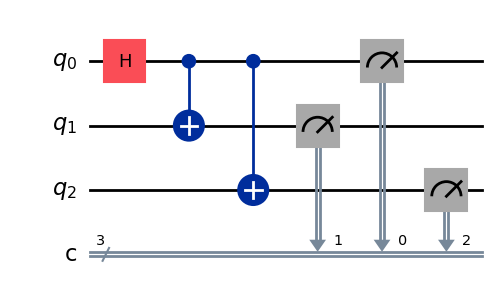

In [ ]:
circuit.draw(output='mpl')

Saving the output

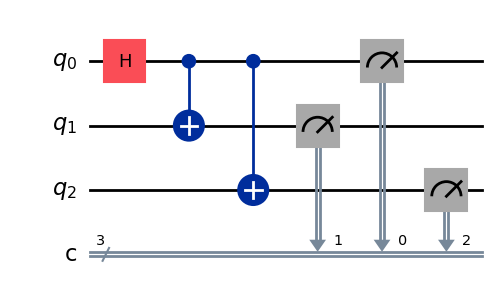

In [ ]:
circuit.draw(output='mpl',filename="circuit.jpeg")

More complex circuits

Quantum circuits can have multiple quantum and classical registers. This example shows:
- Named registers for better organization
- Barrier operations to separate circuit sections
- Measurement across different registers

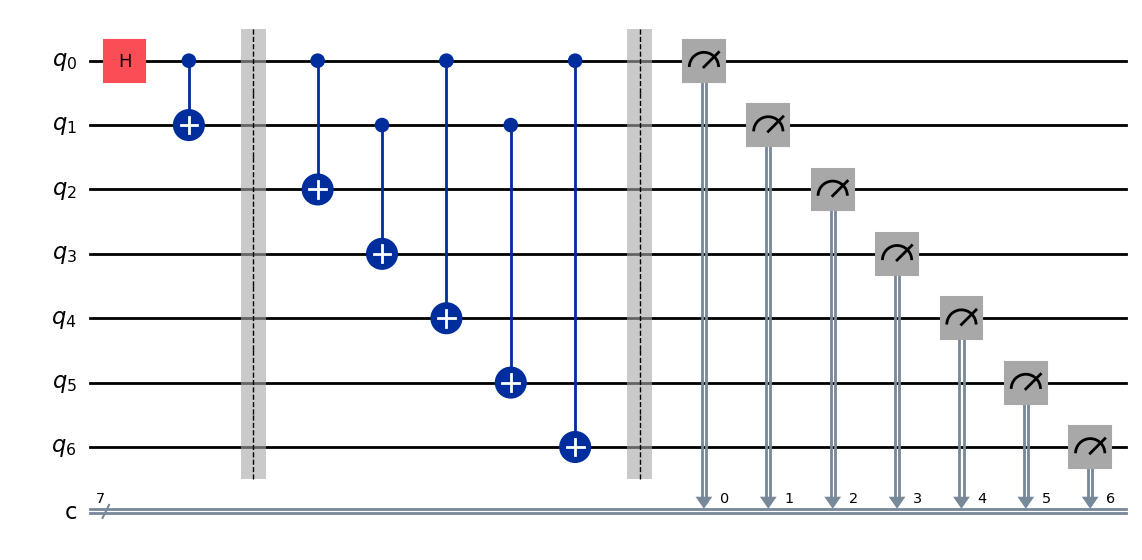

In [ ]:
# create named quantum and classical registers
qreg_q = QuantumRegister(7, 'q')
creg_c = ClassicalRegister(7, 'c')

# build a more complex circuit

circuit = QuantumCircuit(qreg_q, creg_c)

circuit.h(qreg_q[0])
circuit.cx(qreg_q[0], qreg_q[1])

circuit.barrier()

circuit.cx(qreg_q[0], qreg_q[2])
circuit.cx(qreg_q[1], qreg_q[3])

circuit.cx(qreg_q[0], qreg_q[4])
circuit.cx(qreg_q[1], qreg_q[5])

circuit.cx(qreg_q[0], qreg_q[6])

circuit.barrier()

circuit.measure(qreg_q, creg_c)


circuit.draw('mpl')

Reverse Bit Order

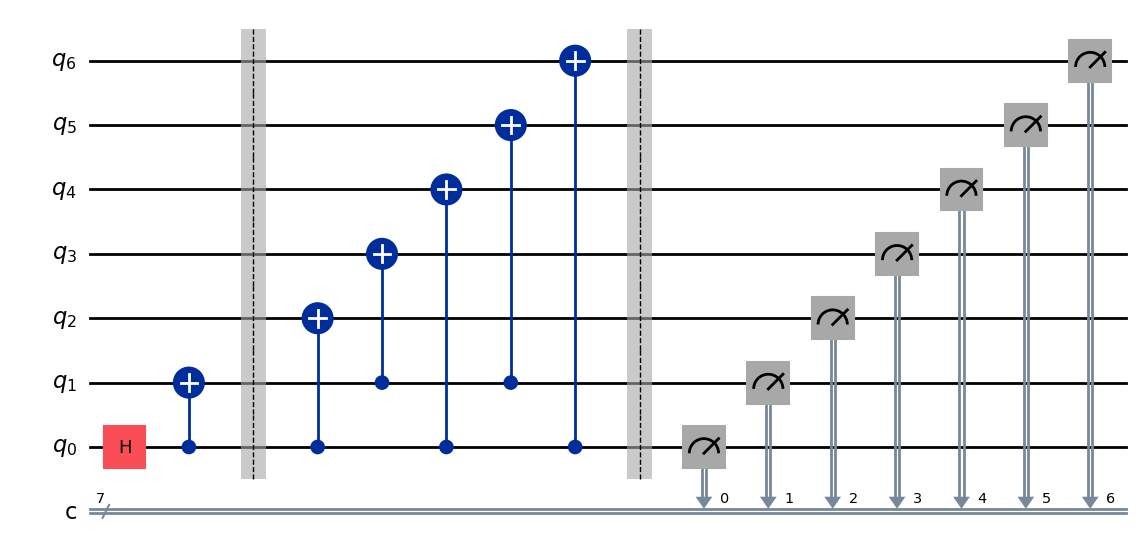

In [ ]:
circuit.draw(output='mpl', reverse_bits=True)

Hide barriers

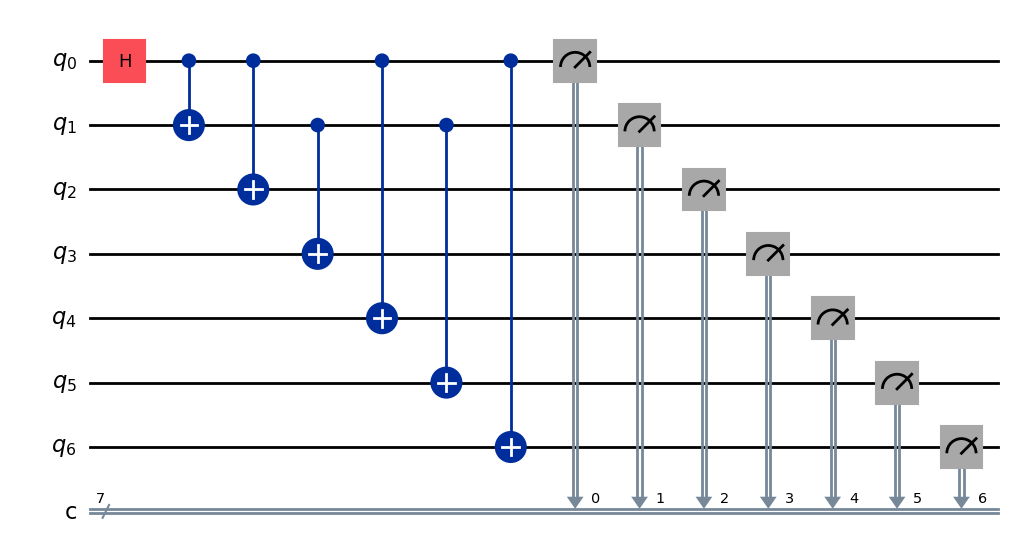

In [ ]:
circuit.draw(output='mpl', plot_barriers=False)

text ouptut with line folding

In [ ]:
# make long cirucits adjustable on screen

circuit.draw(output="text", fold=50)

┌───┐      ░                           ░ ┌─┐»
q_0: ┤ H ├──■───░───■─────────■─────────■───░─┤M├»
     └───┘┌─┴─┐ ░   │         │         │   ░ └╥┘»
q_1: ─────┤ X ├─░───┼────■────┼────■────┼───░──╫─»
          └───┘ ░ ┌─┴─┐  │    │    │    │   ░  ║ »
q_2: ───────────░─┤ X ├──┼────┼────┼────┼───░──╫─»
                ░ └───┘┌─┴─┐  │    │    │   ░  ║ »
q_3: ───────────░──────┤ X ├──┼────┼────┼───░──╫─»
                ░      └───┘┌─┴─┐  │    │   ░  ║ »
q_4: ───────────░───────────┤ X ├──┼────┼───░──╫─»
                ░           └───┘┌─┴─┐  │   ░  ║ »
q_5: ───────────░────────────────┤ X ├──┼───░──╫─»
                ░                └───┘┌─┴─┐ ░  ║ »
q_6: ───────────░─────────────────────┤ X ├─░──╫─»
                ░                     └───┘ ░  ║ »
c: 7/══════════════════════════════════════════╩═»
                                               0 »
«                       
«q_0: ──────────────────
«     ┌─┐               
«q_1: ┤M├───────────────
«     └╥┘┌─┐            
«q_2: ─╫─┤M├────────────
«      ║ └╥┘┌─┐         
«q_3: ─╫──╫─┤M├─────────
«      ║  ║ └╥┘┌─┐      
«q_4: ─╫──╫──╫─┤M├──────
«      ║  ║  ║ └╥┘┌─┐   
«q_5: ─╫──╫──╫──╫─┤M├───
«      ║  ║  ║  ║ └╥┘┌─┐
«q_6: ─╫──╫──╫──╫──╫─┤M├
«      ║  ║  ║  ║  ║ └╥┘
«c: 7/═╩══╩══╩══╩══╩══╩═
«      1  2  3  4  5  6

STYLING

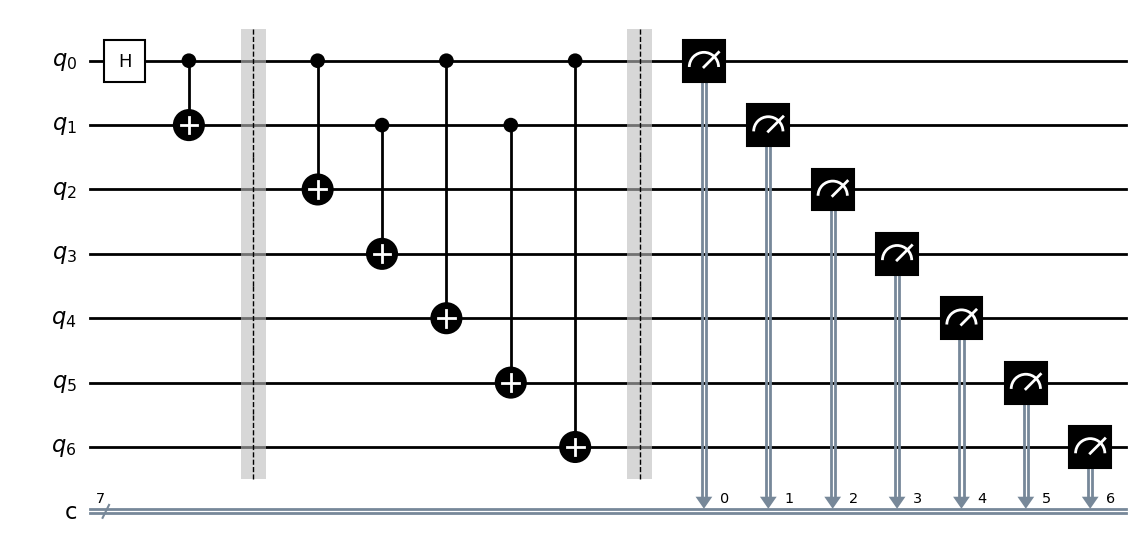

In [ ]:
circuit.draw(output='mpl', style='bw')

Qiskit allows extensive customization of circuit appearance through style dictionaries. This is useful for presentations, teaching materials, or to match publication styles.

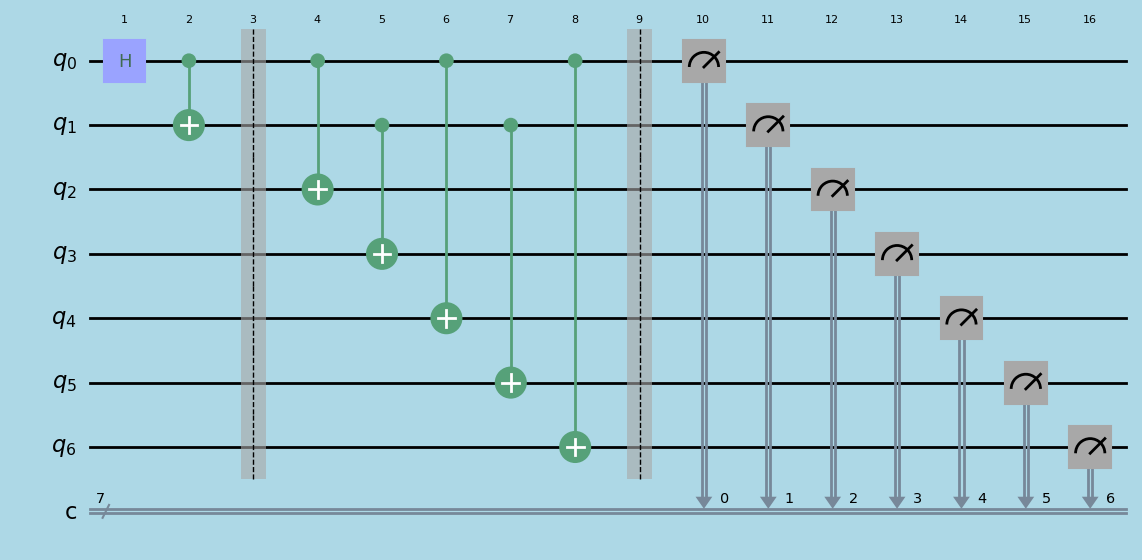

In [ ]:
style = {
    "backgroundcolor": "lightblue",
    "fold": 40,
    "showindex":True,
    "compress": False,
    "displaycolor":{
        "h": [
            "#9AA3FF",
            "#406B51"
        ],
        "cx": [
            "#56A179",
            "#DA8B4F"
        ]
    }
}


circuit.draw(output="mpl", style=style)

Scale Control

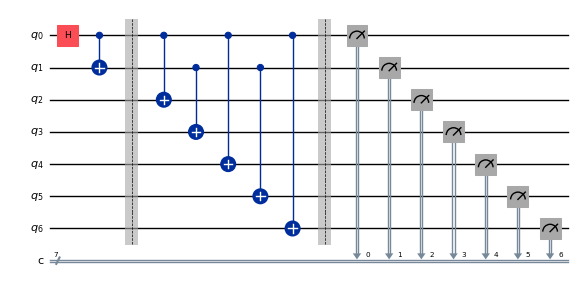

In [ ]:
circuit.draw(output='mpl', scale=0.5)

##`circuit_drawer` function

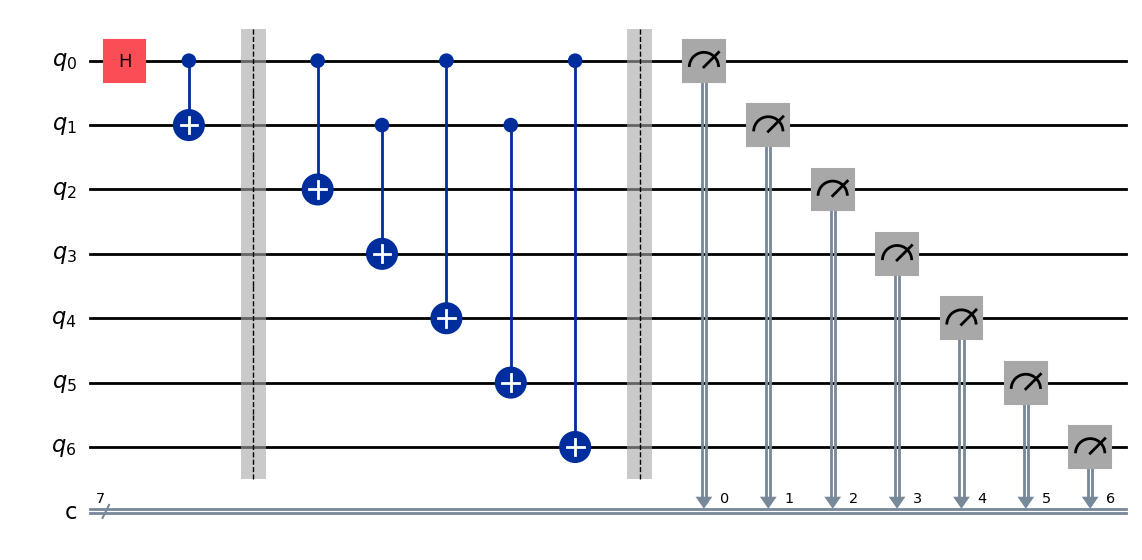

In [ ]:
from qiskit.visualization import circuit_drawer
#alternative of draw
circuit_drawer(circuit, output='mpl')